# Test Model No DCT (1 File / 1 Folder)
Notebook ini bisa menguji model image-only (tanpa DCT) untuk:
- Satu file gambar (menampilkan prediksi + confidence %)
- Satu folder gambar (rekap distribusi prediksi, dan akurasi % jika label folder terdeteksi)

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parent
if (PROJECT_ROOT / 'src').exists():
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from model import build_backbone, build_head

In [2]:
# === Ubah sesuai kebutuhan ===
MODEL_PATH = PROJECT_ROOT / 'models/checkpoints/best_efficient_no_dct.pth'
TARGET_PATH = PROJECT_ROOT / 'data/test'  # bisa file atau folder
OUTPUT_DIR = PROJECT_ROOT / 'notebooks/outputs/labeled_predictions'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PREVIEW_MAX = 12  # jumlah maksimum gambar yang ditampilkan di output notebook saat mode folder
PREVIEW_MAX_SIDE = 640  # sisi terpanjang preview di notebook, agar ukuran .ipynb tetap kecil

# Mapping label output model -> nama kelas
LABEL_FOR_INDEX = {0: 'REAL', 1: 'FAKE'}

VALID_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tiff'}
transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

REAL_TOKENS = {'real', 'asli', 'authentic', 'human', 'natural', 'nature'}
FAKE_TOKENS = {'fake', 'ai', 'deepfake', 'synthetic', 'artifice'}

In [3]:
def _try_extract_dct_features(img_pil):
    try:
        from scipy.fft import dctn
        from scipy.stats import skew
    except Exception:
        return None

    y = np.asarray(img_pil.convert('YCbCr'), dtype=np.float32)[:, :, 0]
    h, w = y.shape
    if h < 8 or w < 8:
        y = np.pad(y, ((0, max(8 - h, 0)), (0, max(8 - w, 0))), mode='edge')
        h, w = y.shape
    h8 = (h // 8) * 8
    w8 = (w // 8) * 8
    y = y[:h8, :w8]

    blocks = y.reshape(h8 // 8, 8, w8 // 8, 8).swapaxes(1, 2).reshape(-1, 8, 8)
    dct_blocks = dctn(blocks, axes=(-2, -1), norm='ortho').reshape(-1, 64)

    means = dct_blocks.mean(axis=0)
    variances = dct_blocks.var(axis=0)
    skews = np.nan_to_num(skew(dct_blocks, axis=0, bias=False), nan=0.0)
    feat = np.concatenate([means, variances, skews], axis=0).astype(np.float32)
    feat = np.nan_to_num(feat, nan=0.0, posinf=1e6, neginf=-1e6)
    feat_std = max(float(feat.std()), 1e-6)
    feat = (feat - float(feat.mean())) / feat_std
    feat = np.clip(feat, -1e4, 1e4)
    return torch.from_numpy(feat).unsqueeze(0)


def load_model(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location='cpu')
    dct_dim = int(ckpt.get('dct_dim', 192))

    backbone, feature_dim = build_backbone(log_fn=print)
    head = build_head(feature_dim, dct_dim)

    if 'efficientnet_state_dict' in ckpt:
        backbone.load_state_dict(ckpt['efficientnet_state_dict'])
    elif 'resnet_state_dict' in ckpt:
        backbone.load_state_dict(ckpt['resnet_state_dict'])
    elif 'backbone_state_dict' in ckpt:
        backbone.load_state_dict(ckpt['backbone_state_dict'])
    else:
        raise KeyError(
            'Checkpoint tidak punya backbone state dict. '
            f"Available keys: {sorted(list(ckpt.keys()))}"
        )

    if 'head_state_dict' in ckpt:
        head.load_state_dict(ckpt['head_state_dict'])
    else:
        raise KeyError(
            'Checkpoint tidak punya head state dict. '
            f"Available keys: {sorted(list(ckpt.keys()))}"
        )

    backbone = backbone.to(DEVICE).eval()
    head = head.to(DEVICE).eval()
    return backbone, head, dct_dim



def make_small_preview(img_pil, max_side=640):
    preview = img_pil.copy()
    preview.thumbnail((max_side, max_side), Image.Resampling.LANCZOS)
    return preview

def draw_prediction_box(img_pil, pred_idx, confidence, probs):
    label = LABEL_FOR_INDEX.get(pred_idx, str(pred_idx))
    is_fake = str(label).upper() == 'FAKE'
    color = (220, 40, 40) if is_fake else (40, 180, 80)

    out = img_pil.copy()
    draw = ImageDraw.Draw(out)
    w, h = out.size
    margin = max(2, int(min(w, h) * 0.02))
    line_w = max(2, int(min(w, h) * 0.01))

    draw.rectangle(
        [(margin, margin), (max(margin + 1, w - margin), max(margin + 1, h - margin))],
        outline=color,
        width=line_w,
    )

    text = f"{label} | Conf: {confidence:.2f}%"
    text2 = f"REAL: {probs[0]*100:.1f}% | FAKE: {probs[1]*100:.1f}%"
    try:
        font = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf', max(14, line_w * 4))
    except Exception:
        font = ImageFont.load_default()

    bbox = draw.textbbox((0, 0), text + '\n' + text2, font=font)
    tw = bbox[2] - bbox[0]
    th = bbox[3] - bbox[1]
    tx, ty = margin + 4, margin + 4

    draw.rectangle(
        [(tx - 6, ty - 6), (tx + tw + 6, ty + th + 6)],
        fill=(0, 0, 0, 180),
    )
    draw.text((tx, ty), text + '\n' + text2, fill=(255, 255, 255), font=font)
    return out


@torch.no_grad()
def predict_one(image_path, backbone, head, dct_dim):
    img_pil = Image.open(image_path).convert('RGB')
    img_np = np.array(img_pil)
    image_tensor = transform(image=img_np)['image'].unsqueeze(0).to(DEVICE)

    if dct_dim > 0:
        dct_tensor = _try_extract_dct_features(img_pil)
        if dct_tensor is None:
            raise RuntimeError('Model butuh DCT (dct_dim > 0), tapi SciPy belum tersedia.')
        dct_tensor = dct_tensor.to(DEVICE)
        feats = torch.cat([backbone(image_tensor), dct_tensor], dim=1)
    else:
        feats = backbone(image_tensor)

    logits = head(feats)
    probs = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()
    pred_idx = int(np.argmax(probs))
    confidence = float(probs[pred_idx]) * 100.0
    return pred_idx, probs, confidence, img_pil


def infer_true_label_from_path(p: Path):
    parts = [x.lower() for x in p.parts]
    for token in parts:
        if token in REAL_TOKENS:
            return 0
        if token in FAKE_TOKENS:
            return 1
    return None

Using EfficientNet-B0 pretrained weights
Model loaded | device=cpu | dct_dim=0
Output anotasi disimpan ke: /home/fadhly/comvis/2kripsi/artifice-vs-nature/final-skripsi/notebooks/outputs/labeled_predictions
Preview 1: AI-GPT.jpg


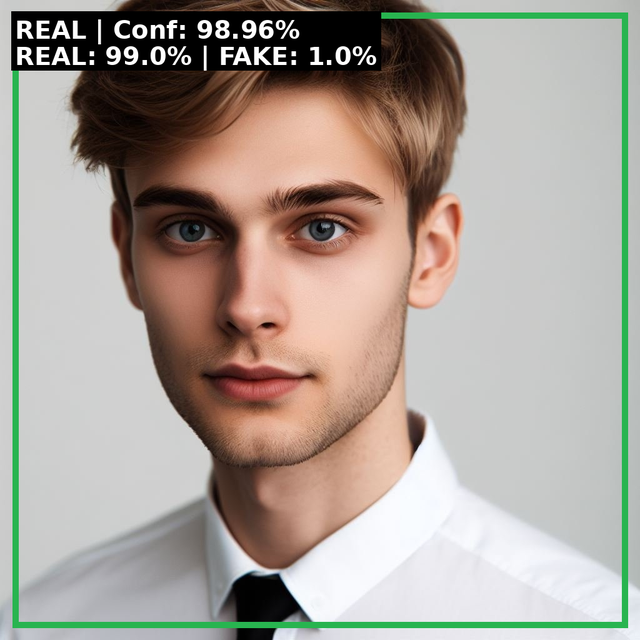

Preview 2: DALL·E-2022-06-28-19.13.15-head-and-shoulder-Medium-format-portrait-photography-of-a-young-beautiful-blond-woman-wearing-a-yellow-kimono-in-a-beautiful-and-foggy-tropical-greenh-copy-800x800.webp


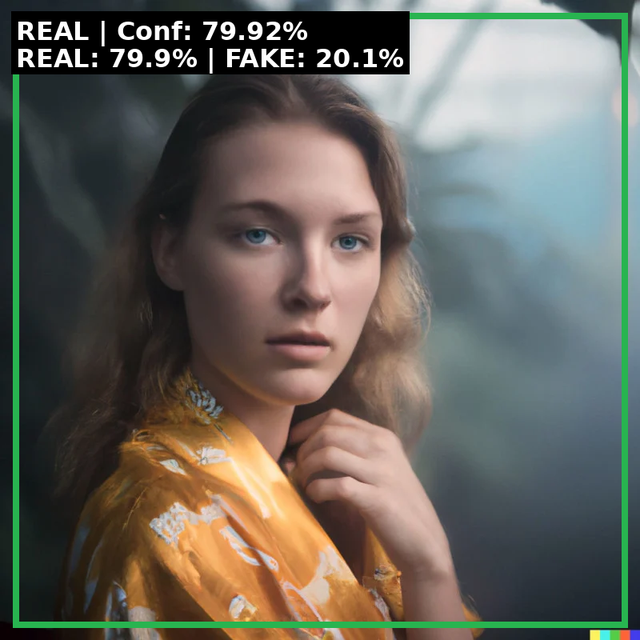

Preview 3: REAL-Nikon-Z7-II-Sample-Image-4.webp


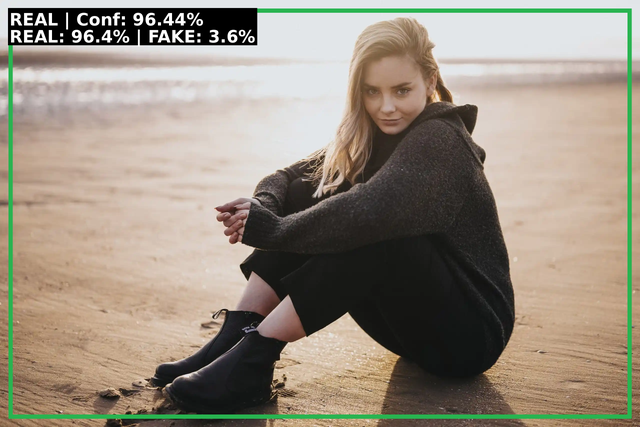

Preview 4: REAL-photo-1542909168-82c3e7fdca5c.jpeg


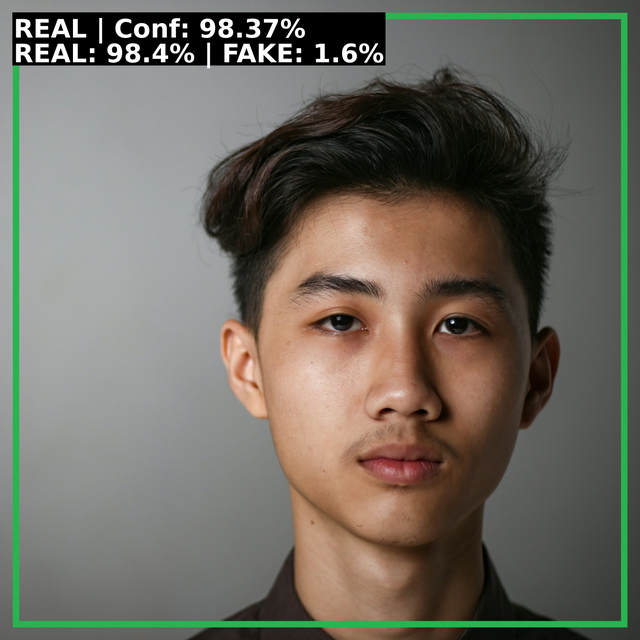

Preview 5: REAL-premium_photo-1664203067979-47448934fd97.jpeg


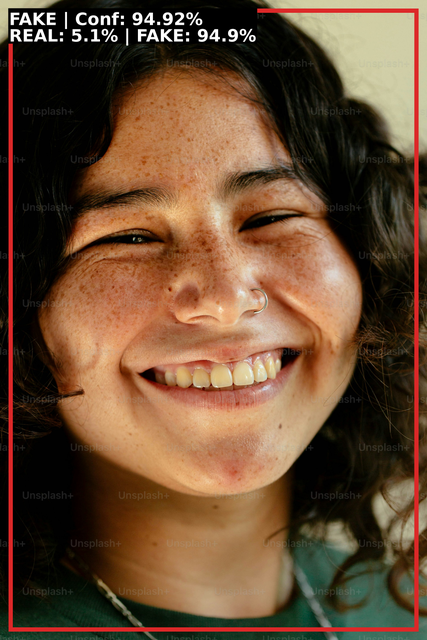

Preview 6: ai-people-showing-support-respect.jpg


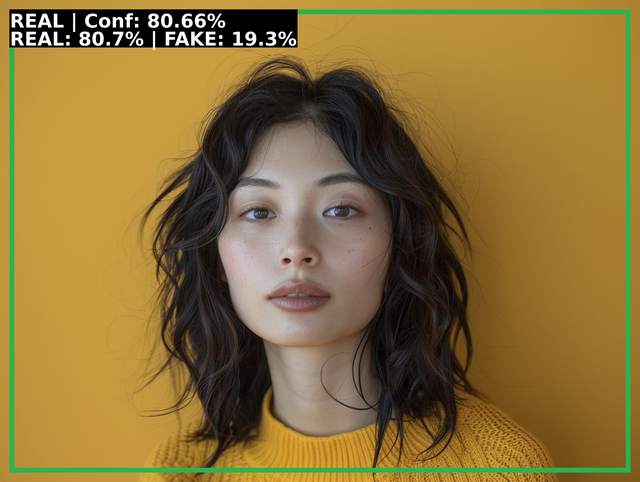

Preview 7: ai-prevention-day.jpg


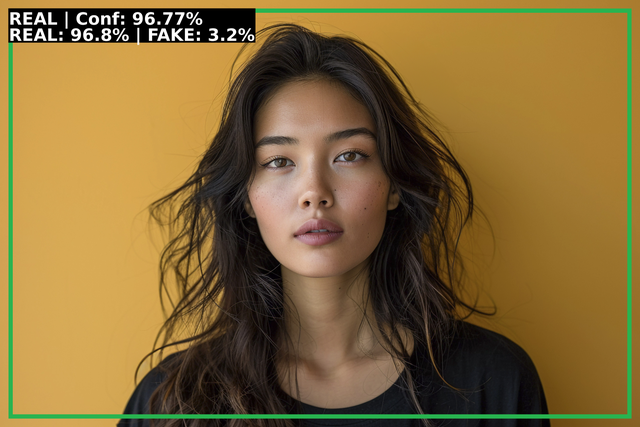

Preview 8: child-ai.jpg


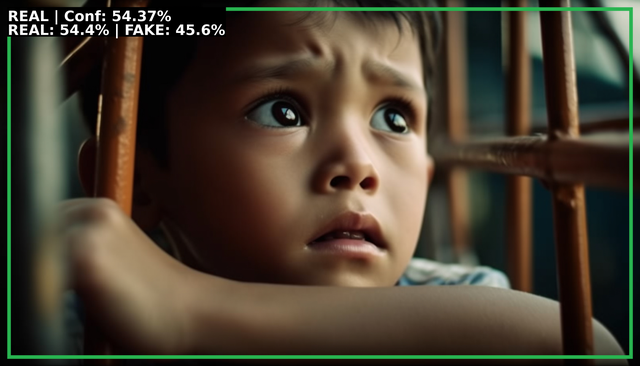

Preview 9: man.jpg


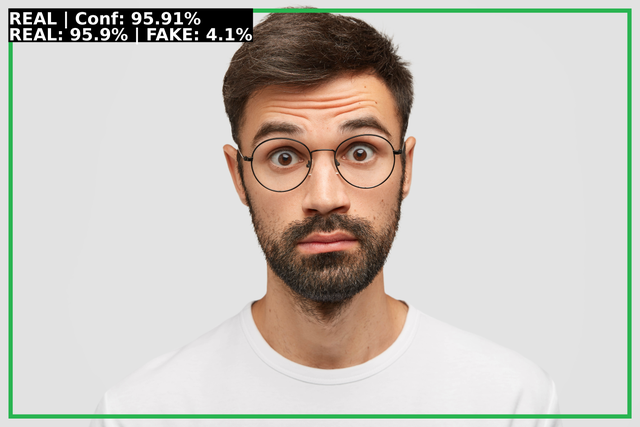

Preview 10: portrait-asian-woman-with-flawless-skin.jpg


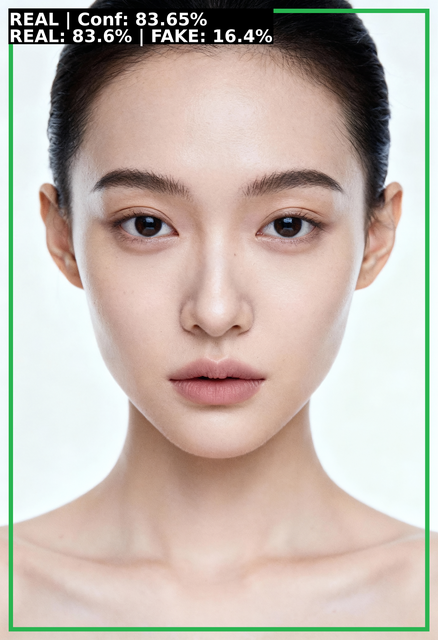

Preview 11: test_compress.jpeg


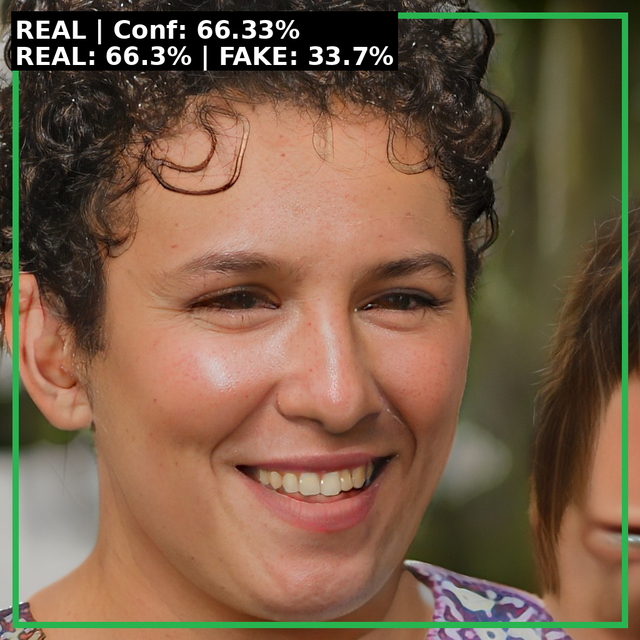

Preview 12: worldface-thai-boy-white-background.jpg


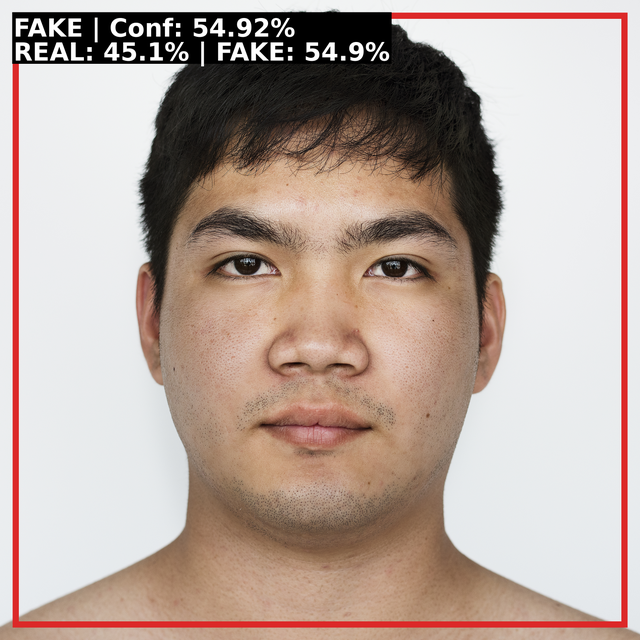

--- FOLDER RESULT ---
Folder             : /home/fadhly/comvis/2kripsi/artifice-vs-nature/final-skripsi/data/test
Total gambar       : 12
Pred REAL          : 10 (83.33%)
Pred FAKE          : 2 (16.67%)
Output folder      : /home/fadhly/comvis/2kripsi/artifice-vs-nature/final-skripsi/notebooks/outputs/labeled_predictions
Preview ditampilkan: 12 gambar
Akurasi tidak dihitung karena label folder tidak terdeteksi.


In [4]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(f'Checkpoint tidak ditemukan: {MODEL_PATH}')

backbone, head, dct_dim = load_model(MODEL_PATH)
print(f'Model loaded | device={DEVICE} | dct_dim={dct_dim}')

target = Path(TARGET_PATH)
if not target.exists():
    raise FileNotFoundError(f'TARGET_PATH tidak ditemukan: {target}')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Output anotasi disimpan ke: {OUTPUT_DIR}')

if target.is_file():
    pred_idx, probs, conf, img_pil = predict_one(target, backbone, head, dct_dim)
    label = LABEL_FOR_INDEX.get(pred_idx, pred_idx)
    labeled_img = draw_prediction_box(img_pil, pred_idx, conf, probs)

    out_path = OUTPUT_DIR / target.name
    labeled_img.save(out_path)

    print('--- SINGLE FILE RESULT ---')
    print(f'File       : {target}')
    print(f'Prediksi   : {label}')
    print(f'Confidence : {conf:.2f}%')
    print(f'Prob kelas : {probs}')
    print(f'Output img : {out_path}')
    display(make_small_preview(labeled_img, PREVIEW_MAX_SIDE))
else:
    image_paths = sorted([p for p in target.rglob('*') if p.is_file() and p.suffix.lower() in VALID_EXTS])
    if len(image_paths) == 0:
        raise RuntimeError('Tidak ada gambar valid di folder.')

    preds = []
    gt = []
    preview_count = 0

    for p in image_paths:
        pred_idx, probs, conf, img_pil = predict_one(p, backbone, head, dct_dim)
        preds.append(pred_idx)
        gt.append(infer_true_label_from_path(p))

        rel_path = p.relative_to(target)
        out_path = OUTPUT_DIR / rel_path
        out_path.parent.mkdir(parents=True, exist_ok=True)

        labeled_img = draw_prediction_box(img_pil, pred_idx, conf, probs)
        labeled_img.save(out_path)

        if preview_count < PREVIEW_MAX:
            print(f'Preview {preview_count + 1}: {rel_path}')
            display(make_small_preview(labeled_img, PREVIEW_MAX_SIDE))
            preview_count += 1

    n_total = len(preds)
    n_real = int(sum(1 for x in preds if x == 0))
    n_fake = int(sum(1 for x in preds if x == 1))

    print('--- FOLDER RESULT ---')
    print(f'Folder             : {target}')
    print(f'Total gambar       : {n_total}')
    print(f'Pred REAL          : {n_real} ({(100.0 * n_real / n_total):.2f}%)')
    print(f'Pred FAKE          : {n_fake} ({(100.0 * n_fake / n_total):.2f}%)')
    print(f'Output folder      : {OUTPUT_DIR}')
    print(f'Preview ditampilkan: {min(PREVIEW_MAX, n_total)} gambar')

    valid_pairs = [(y, p) for y, p in zip(gt, preds) if y is not None]
    if len(valid_pairs) > 0:
        y_true = np.array([x[0] for x in valid_pairs], dtype=np.int64)
        y_pred = np.array([x[1] for x in valid_pairs], dtype=np.int64)
        acc = float((y_true == y_pred).mean()) * 100.0
        print(f'Akurasi (berlabel) : {acc:.2f}% dari {len(valid_pairs)} gambar')
    else:
        print('Akurasi tidak dihitung karena label folder tidak terdeteksi.')